In [392]:
import numpy as np
from HybridCORELS import *
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd


In [393]:
dataset_name = "compas" # Supported: "compas", "adult", "acs_employ"

# Load data using built-in method
X, y, features, prediction = load_from_csv("../examples/data/%s_mined.csv" %dataset_name)

In [394]:
prediction

'Recidivate-Within-Two-Years'

In [15]:
for i in features :
    if 'Male' in i:
        print(i)

Gender=Male
Gender=Male && Juvenile-Felonies=0
Gender=Male && Juvenile-Crimes=0
Age>=30 && Gender=Male
Age=24-40 && Gender=Male
Race=African-American && Gender=Male
Prior-Crimes=1-3 && Gender=Male
Current-Charge-Degree=Misdemeanor && Gender=Male
Prior-Crimes>3 && Gender=Male
Race=Caucasian && Gender=Male
Age=24-30 && Gender=Male
Age<=40 && Gender=Male
Prior-Crimes=0 && Gender=Male
Age=18-25 && Gender=Male
neg_Gender=Male
Prior-Crimes>5 && Gender=Male
Age<=45 && Gender=Male
Juvenile-Crimes=1-3 && Gender=Male
Age=18-22 && Gender=Male
Race=Hispanic && Gender=Male
Race=Other && Gender=Male
Juvenile-Felonies=1-3 && Gender=Male
Age=18-20 && Gender=Male
Juvenile-Crimes>3 && Gender=Male


In [19]:
compas_data = pd.DataFrame(X, columns=features)

In [395]:
[i for i in features if 'Male' in i]

['Gender=Male',
 'Gender=Male && Juvenile-Felonies=0',
 'Gender=Male && Juvenile-Crimes=0',
 'Age>=30 && Gender=Male',
 'Age=24-40 && Gender=Male',
 'Race=African-American && Gender=Male',
 'Prior-Crimes=1-3 && Gender=Male',
 'Current-Charge-Degree=Misdemeanor && Gender=Male',
 'Prior-Crimes>3 && Gender=Male',
 'Race=Caucasian && Gender=Male',
 'Age=24-30 && Gender=Male',
 'Age<=40 && Gender=Male',
 'Prior-Crimes=0 && Gender=Male',
 'Age=18-25 && Gender=Male',
 'neg_Gender=Male',
 'Prior-Crimes>5 && Gender=Male',
 'Age<=45 && Gender=Male',
 'Juvenile-Crimes=1-3 && Gender=Male',
 'Age=18-22 && Gender=Male',
 'Race=Hispanic && Gender=Male',
 'Race=Other && Gender=Male',
 'Juvenile-Felonies=1-3 && Gender=Male',
 'Age=18-20 && Gender=Male',
 'Juvenile-Crimes>3 && Gender=Male']

In [396]:
compas_data['Gender=Male'].sum()

np.uint64(5819)

In [397]:
compas_data.head()

,neg_Race=Native-American,neg_Juvenile-Felonies>3,neg_Race=Asian,neg_Juvenile-Crimes>5,neg_Juvenile-Crimes>3,neg_Age=18-20,neg_Juvenile-Felonies=1-3,Juvenile-Felonies=0,neg_Race=Other,neg_Race=Hispanic,...,Juvenile-Crimes>3 && Prior-Crimes>3,Race=Other && Age=18-25,Juvenile-Crimes>3 && Race=African-American,Juvenile-Felonies=1-3 && Prior-Crimes=1-3,Age=18-20 && Juvenile-Crimes=1-3,Race=Other && Age<=45,Juvenile-Crimes>3 && Prior-Crimes>5,Race=Hispanic && Prior-Crimes>5,Juvenile-Crimes>3 && Age=24-40,Juvenile-Crimes=1-3 && Prior-Crimes=0
0,1,1,1,1,1,1,1,1,0,1,...,0,0,0,0,0,1,0,0,0,0
1,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,1,1,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0


In [398]:
# Generate train and test sets
random_state_param = 42
train_proportion = 0.8
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1.0 - train_proportion, shuffle=True, random_state=random_state_param)

# Set parameters
corels_params = {'policy':"objective", 'max_card':1, 'n_iter':10**5, 'min_support':0.05, 'verbosity':["hybrid"]} # Add "progress" to verbosity to display detailed information about the search!
alpha_value = 2 # Specialization Coefficient (see Section 3.1.2 of our paper)
lambdaValue = 0.001 # Regularization coefficient for sparsity
beta_value = min([ (1 / X_train.shape[0]) / 2, lambdaValue / 2]) # Regularization coefficient for transparency - this value ensures that transparency will break ties between identically accurate and sparse models
min_coverage = 0.90 # Desired minimum transparency (coverage of the interpretable part)

# Define a hybrid model
bbox = RandomForestClassifier(random_state=42, min_samples_split=10, max_depth=10)

In [52]:
hyb_model = HybridCORELSPostClassifier(black_box_classifier=bbox,  
                                        bb_pretrained=False,
                                        beta=beta_value, 
                                        c= lambdaValue, 
                                        min_coverage=min_coverage, 
                                        **corels_params)#"progress"

Hybrid model created!


In [400]:
# Train the hybrid model
# Set resources used to train the prefix (interpretable part of the hybrid model)
t_limit = 60 # Seconds
m_limit = 4000 # MB
hyb_model.fit(X_train, y_train, features=features, prediction_name=prediction, time_limit=t_limit, memory_limit=m_limit)

print("Status = ", hyb_model.get_status()) # Indicates whether the training was performed to optimality or if any other ending condition was reached

print("=> Trained model :", hyb_model)

Training the BB part on the entire dataset
Fitting the interpretable part...
Interpretable part coverage =  0.9357130479986138
Interpretable part accuracy =  0.654074074074074
Black-Box part accuracy =  0.7897574123989218
Training accuracy overall =  0.6627967423323514
Status =  max_nodes_reached
=> Trained model : HybridCORELSPostClassifier
if [Age=18-22 && Gender=Male]:
  Recidivate-Within-Two-Years = True(support 571, accuracy 0.70403)
else if [Prior-Crimes>5 && Juvenile-Felonies=0]:
  Recidivate-Within-Two-Years = True(support 1069, accuracy 0.71656)
else if [Juvenile-Crimes=0]:
  Recidivate-Within-Two-Years = False(support 3760, accuracy 0.62872)
else 
    default: RandomForestClassifier(max_depth=10, min_samples_split=10, random_state=42)(support 371, accuracy 0.790)


In [407]:
# Evaluate training performances
preds_train, preds_types_train = hyb_model.predict_with_type(X_train)
preds_types_counts_train = np.unique(preds_types_train, return_counts=True)
index_one_train = np.where(preds_types_counts_train[0] == 1)
cover_rate_train = preds_types_counts_train[1][index_one_train][0]/np.sum(preds_types_counts_train[1])
print("=> Training accuracy = ", np.mean(preds_train == y_train))
print("=> Training transparency = ", cover_rate_train)

=> Training accuracy =  0.6627967423323514
=> Training transparency =  0.9357130479986138


In [415]:
preds_types_counts_train[1][np.where(preds_types_counts_train[0] == 1)[0]]/ X_train.shape[0]

array([0.93571305])

In [496]:
captured_indices = np.where(preds_types_train == 1, True, False)

In [ ]:
preds_types_train == 1

array([ True,  True,  True, ...,  True,  True,  True])

In [ ]:
X_train[:, features.index('Gender=Male')][captured_indices]

np.uint64(4303)

In [112]:
test = np.where(np.where(np.array([1,2,3,4,5])>=3, True, False))

In [115]:
np.array([1,2,3,4,5])[list(test)]

array([[3, 4, 5]])

In [117]:
preds_types_counts_train[1]

array([ 371, 5400])

In [119]:
X_train.shape

(5771, 230)

In [124]:
np.where(features == 'Gender=Male')

/var/folders/_3/2fj907ps1j183h71ncfrxqcm0000gn/T/ipykernel_52110/1177533722.py:1: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(cond).nonzero()` if the old behavior was intended. If the context of this warning is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.
  np.where(features == 'Gender=Male')


(array([], dtype=int64),)

In [129]:
features.index('Gender=Male')

14

In [434]:
all_men = X_train[:, features.index('Gender=Male')].sum() #number of men
all_men

np.uint64(4626)

In [133]:
X_train.shape[0]- X_train[:, features.index('Gender=Male')].sum() #number of women

np.uint64(1145)

In [469]:
np.where(X_train[:, features.index('Gender=Male')]==1)

(array([   0,    1,    3, ..., 5767, 5769, 5770]),)

In [425]:
np.where(X_train[:, features.index('Gender=Male')]==1)[0].shape[0]

4626

In [471]:
male_transparent = preds_types_train[np.where(X_train[:, features.index('Gender=Male')]==1)[0]].sum() # all male goes through the interpretable part
male_transparent

np.float64(4303.0)

In [447]:
#or

X_train[X_train[:, features.index('Gender=Male')]==1].shape[0]



4626

In [458]:
((X_train[:,features.index('Gender=Male')]==1)[captured_indices]).sum()

np.int64(4303)

In [429]:
male_transparent

np.float64(4303.0)

In [146]:
X_train[:, features.index('Gender=Male')].sum() - preds_types_train[np.where(X_train[:, features.index('Gender=Male')]==1)[0]].sum()

np.float64(323.0)

In [233]:
male_trans_percent = ((male_transparent)/ (all_men ))* 100
male_trans_percent

np.float64(93.01772589710333)

In [167]:
print(f'the percentage of men going through the interpretable part is {male_trans_percent:.2f}')

the percentage of men going through the interpretable part is 93.02


In [168]:
# Evaluate test performances
preds_test, preds_types_test = hyb_model.predict_with_type(X_test)
preds_types_counts_test = np.unique(preds_types_test, return_counts=True)
index_one_test = np.where(preds_types_counts_test[0] == 1)
cover_rate_test = preds_types_counts_test[1][index_one_test][0]/np.sum(preds_types_counts_test[1])
print("=> Test accuracy = ", np.mean(preds_test == y_test))
print("=> Test transparency = ", cover_rate_test)

=> Test accuracy =  0.665973665973666
=> Test transparency =  0.9327789327789328


In [481]:
all_men_test = X_test[:, features.index('Gender=Male')].sum() #number of men
all_men_test

np.uint64(1193)

In [487]:
preds_types_test[X_test[:, features.index('Gender=Male')]==1].sum()

np.float64(1110.0)

In [174]:
male_transparent_test = preds_types_test[np.where(X_test[:, features.index('Gender=Male')]==1)[0]].sum() # all male goes through the interpretable part

In [175]:
male_transparent_test

np.float64(1110.0)

In [180]:
male_trans_percent_test = (male_transparent_test/all_men_test)*100

In [182]:
print(f'the percentage of men going through the interpretable part is {male_trans_percent_test:.2f}')

the percentage of men going through the interpretable part is 93.04


In [ ]:
# for female
X_train[:, features.index('Gender=Male')].sum() #number of men

In [204]:
all_women = (X_train[:, features.index('Gender=Male')]==0).sum() #all women

In [224]:
all_women

np.int64(1145)

In [193]:
np.where(X_train[:, features.index('Gender=Male')]==0)[0].shape

(1145,)

In [ ]:
female_trans=preds_types_train[X_train[:, features.index('Gender=Male')]==0].sum() #all women going through the interpretable part

In [206]:
female_trans_percentage = (female_trans/all_women)*100

In [207]:
female_trans_percentage

np.float64(95.80786026200873)

In [208]:
print(f'the percentage of men going through the interpretable part is {male_trans_percent_test:.2f}')

the percentage of men going through the interpretable part is 93.04


In [209]:
#evalute test

all_women_test = (X_test[:, features.index('Gender=Male')]==0).sum() #all women
all_women_test

np.int64(250)

In [211]:
female_trans_test = preds_types_test[X_test[:, features.index('Gender=Male')]==0].sum() #all women going through the black-box part
female_trans_test

np.float64(236.0)

In [212]:
female_trans_test_percentage = (female_trans_test/all_women_test)*100

In [214]:
print(f'the percentage of men going through the interpretable part is {female_trans_test_percentage:.2f}')

the percentage of men going through the interpretable part is 94.40


In [ ]:
#making this more beautiful and organized

In [488]:
all_men_indices =  X_train[:, features.index('Gender=Male')]==1

In [491]:
all_men_indices.sum()

np.int64(4626)

In [222]:
all_woman_indices = np.logical_not(all_men_indices)

In [228]:
preds_types_train [all_men_indices].sum()

np.float64(4303.0)

In [231]:
preds_types_train [all_woman_indices].sum()

np.float64(1097.0)

In [232]:
preds_types_train [all_men_indices].sum()/ all_men_indices.sum() *100

np.float64(93.01772589710333)

In [535]:
[i for i in features if 'Age' in i and 'neg' not in i and '&&' not in i]

['Age>=30',
 'Age=24-40',
 'Age=24-30',
 'Age<=40',
 'Age=18-25',
 'Age<=45',
 'Age=18-22',
 'Age=18-20']

In [538]:
features.index('Gender=Male')

14

In [539]:
#combined condition
[i for i,j in enumerate(features) if j in ['Gender=Male','Age<=45']]

[14, 80]

In [ ]:
np.all (X_train[:, [i for i,j in enumerate(features) if j in ['Gender=Male','Age<=45']]], axis=1) #all condition applied

array([False,  True, False, ..., False, False, False])

In [546]:
preds_types_train[np.all (X_train[:, [i for i,j in enumerate(features) if j in ['Gender=Male','Age<=45']]], axis=1) ].sum() #men <=45 going through interpretable part

np.float64(996.0)

In [ ]:

(X_train[:, features.index('Gender=Male')]==1).sum() #all men

np.int64(4626)

In [ ]:
preds_types_train[X_train[:, features.index('Gender=Male')]==1].sum() #men goes through transparent part 

np.float64(4303.0)

In [547]:


class FairnessMeasure():
    def __init__(self,X ,features: list, condition:list):
        """
        This class computes fairness measures based on transparency for a given condition.
        X: np.ndarray
            it could be train or test data.
        features: list
            List of feature names corresponding to the columns of X.
        condition: list
            List of feature names that define the condition. The condition is the intersection of these features being true (1)."""
        self.X = X
        self.features = features
        self.condition = condition
    #slice the data based on the condition
    def set_condition(self):  
        indices_of_features = [i for i,j in enumerate(self.features) if j in self.condition]
        condition_indices = np.all((self.X[:,indices_of_features]),axis=1)
        return condition_indices
    # compute of percentage of interpretable samples for the given condition
    def compute_fairness(self, preds_types,complement = False):
        condition_indices = self.set_condition()
        if complement:
            condition_indices = np.logical_not(condition_indices)
        total_count = condition_indices.sum() # total number of samples satisfying the condition
        interpretable_count = preds_types[condition_indices].sum() # number of samples satisfying the condition going through the interpretable part
        percentage_interpretable = (interpretable_count / total_count) * 100 if total_count > 0 else 0
        return {
            "condition": self.condition,
            "total_count": int(total_count),
            "interpretable_count": int(interpretable_count),
            "percentage_interpretable": '%.2f' % percentage_interpretable
        }
    



In [554]:
fairness_gender = FairnessMeasure(X_train, features, ['Gender=Male'])

In [564]:
fairness_gender.compute_fairness(preds_types_train, complement= False)['percentage_interpretable']

'93.02'

In [556]:
fairness_gender.condition

['Gender=Male']

In [308]:
condition = ['neg_Race=Asian','neg_Age=18-20']

In [309]:
fairness_samplemulti = FairnessMeasure(X_train, features, condition)

In [311]:
fairness_samplemulti.set_condition().sum()

np.int64(5561)

In [329]:
[i for i in features if 'Age=' in i and '&&' not in i and 'neg' not in i ]


['Age=24-40', 'Age=24-30', 'Age=18-25', 'Age=18-22', 'Age=18-20']

In [346]:
[i for i in features if 'Gender=' in i and '&&' not in i  ]

['Gender=Male', 'neg_Gender=Male']

In [ ]:
# what are the Sensitive Demographic Attributes 
# how different the transparency rates should be to be considered unfair??
#race
#gender
#age


In [388]:
race_groups = [i for i in features if 'Race' in i  and 'neg' not in i and '&&' not in i ]
race_groups

['Race=African-American', 'Race=Caucasian', 'Race=Hispanic', 'Race=Other']

In [389]:
for i in race_groups:
    condition = [i]
    fairness= FairnessMeasure(X_train, features, condition)
    print(fairness.compute_fairness(preds_types_train, complement= False))


{'condition': ['Race=African-American'], 'total_count': 2965, 'interpretable_count': 2704, 'percentage_interpretable': '91.20'}
{'condition': ['Race=Caucasian'], 'total_count': 1949, 'interpretable_count': 1867, 'percentage_interpretable': '95.79'}
{'condition': ['Race=Hispanic'], 'total_count': 520, 'interpretable_count': 500, 'percentage_interpretable': '96.15'}
{'condition': ['Race=Other'], 'total_count': 295, 'interpretable_count': 289, 'percentage_interpretable': '97.97'}


In [378]:
#calculate the negative
for i in race_groups:
    condition = [i]
    fairness= FairnessMeasure(X_train, features, condition)
    print(fairness.compute_fairness(preds_types_train, complement= True))

{'condition': ['Race=African-American'], 'total_count': 2806, 'interpretable_count': 2696, 'percentage_interpretable': '96.08'}
{'condition': ['Race=Caucasian'], 'total_count': 3822, 'interpretable_count': 3533, 'percentage_interpretable': '92.44'}
{'condition': ['Race=Hispanic'], 'total_count': 5251, 'interpretable_count': 4900, 'percentage_interpretable': '93.32'}
{'condition': ['Race=Other'], 'total_count': 5476, 'interpretable_count': 5111, 'percentage_interpretable': '93.33'}


In [390]:
race_groups_neg =[i for i in features if 'Race' in i  and 'neg'  in i and '&&' not in i ]
race_groups_neg

['neg_Race=Native-American',
 'neg_Race=Asian',
 'neg_Race=Other',
 'neg_Race=Hispanic',
 'neg_Race=Caucasian',
 'neg_Race=African-American']

In [380]:
for i in race_groups_neg:
    condition = [i]
    fairness= FairnessMeasure(X_train, features, condition)
    print(fairness.compute_fairness(preds_types_train, complement= False))

{'condition': ['neg_Race=Native-American'], 'total_count': 5756, 'interpretable_count': 5387, 'percentage_interpretable': '93.59'}
{'condition': ['neg_Race=Asian'], 'total_count': 5744, 'interpretable_count': 5373, 'percentage_interpretable': '93.54'}
{'condition': ['neg_Race=Other'], 'total_count': 5476, 'interpretable_count': 5111, 'percentage_interpretable': '93.33'}
{'condition': ['neg_Race=Hispanic'], 'total_count': 5251, 'interpretable_count': 4900, 'percentage_interpretable': '93.32'}
{'condition': ['neg_Race=Caucasian'], 'total_count': 3822, 'interpretable_count': 3533, 'percentage_interpretable': '92.44'}
{'condition': ['neg_Race=African-American'], 'total_count': 2806, 'interpretable_count': 2696, 'percentage_interpretable': '96.08'}


In [391]:
for i in race_groups_neg:
    condition = [i]
    fairness= FairnessMeasure(X_train, features, condition)
    print(fairness.compute_fairness(preds_types_train, complement= True))

{'condition': ['neg_Race=Native-American'], 'total_count': 15, 'interpretable_count': 13, 'percentage_interpretable': '86.67'}
{'condition': ['neg_Race=Asian'], 'total_count': 27, 'interpretable_count': 27, 'percentage_interpretable': '100.00'}
{'condition': ['neg_Race=Other'], 'total_count': 295, 'interpretable_count': 289, 'percentage_interpretable': '97.97'}
{'condition': ['neg_Race=Hispanic'], 'total_count': 520, 'interpretable_count': 500, 'percentage_interpretable': '96.15'}
{'condition': ['neg_Race=Caucasian'], 'total_count': 1949, 'interpretable_count': 1867, 'percentage_interpretable': '95.79'}
{'condition': ['neg_Race=African-American'], 'total_count': 2965, 'interpretable_count': 2704, 'percentage_interpretable': '91.20'}


In [385]:
print('the following is for train set:')
for i in [i for i in features if 'Gender=' in i and '&&' not in i  ]:
    condition = [i]
    fairness= FairnessMeasure(X_train, features, condition)
    print(fairness.compute_fairness(preds_types_train, complement= False))

the following is for train set:
{'condition': ['Gender=Male'], 'total_count': 4626, 'interpretable_count': 4303, 'percentage_interpretable': '93.02'}
{'condition': ['neg_Gender=Male'], 'total_count': 1145, 'interpretable_count': 1097, 'percentage_interpretable': '95.81'}


In [387]:
#for test 
print('the following is for test set:')
for i in [i for i in features if 'Gender=' in i and '&&' not in i  ]:
    condition = [i]
    fairness= FairnessMeasure(X_test, features, condition)
    print(fairness.compute_fairness(preds_types_test, complement= False))

the following is for test set:
{'condition': ['Gender=Male'], 'total_count': 1193, 'interpretable_count': 1110, 'percentage_interpretable': '93.04'}
{'condition': ['neg_Gender=Male'], 'total_count': 250, 'interpretable_count': 236, 'percentage_interpretable': '94.40'}


In [557]:
#from now on , we will caluculate the gender fairness for both train and test sets but for many differnt random seeds

X_train.shape

(5771, 230)

In [561]:
int(X.shape[0]*0.8)

5771

In [572]:
## do the statistical hypotesis test for comparing transparency rates between different groups

sub_group_acc = {'Male': ['100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '92.81', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '88.86', '94.83', '100.00', '95.43', '100.00', '100.00', '100.00', '90.90', '100.00', '95.35', '100.00', '100.00', '100.00', '100.00', '92.52', '100.00', '93.02', '100.00', '100.00', '100.00', '100.00', '100.00', '91.54', '100.00', '93.07', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '92.61', '100.00', '100.00', '100.00', '100.00', '88.87', '100.00', '100.00', '100.00', '90.40', '94.70', '100.00', '92.13', '100.00', '100.00', '100.00', '100.00', '94.48', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '93.13', '100.00', '100.00', '91.13', '93.01', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00'], 'Female': ['52.87', '49.95', '54.14', '53.46', '48.21', '48.73', '53.99', '53.58', '54.45', '53.76', '49.26', '52.61', '53.49', '51.65', '54.16', '54.28', '95.62', '54.16', '53.47', '53.19', '54.38', '52.27', '52.79', '53.26', '54.30', '53.14', '95.48', '96.40', '54.34', '93.46', '54.22', '52.94', '54.26', '95.50', '54.09', '92.82', '53.98', '54.52', '54.32', '54.00', '94.21', '54.15', '95.81', '54.09', '53.60', '52.63', '53.59', '53.08', '95.92', '53.18', '95.41', '52.97', '53.86', '53.09', '53.62', '53.29', '53.11', '53.69', '51.64', '53.21', '94.07', '52.22', '52.97', '52.65', '52.76', '95.07', '52.98', '54.27', '52.94', '95.69', '96.41', '52.64', '96.16', '53.08', '53.20', '53.36', '52.11', '96.15', '53.76', '53.56', '52.80', '52.76', '53.28', '53.22', '95.42', '52.98', '53.24', '96.07', '91.78', '52.96', '54.08', '53.12', '53.28', '52.10', '53.93', '54.08', '49.09', '53.18', '48.61', '53.07']}

In [577]:
sub_group_acc.keys()

dict_keys(['Male', 'Female'])

In [583]:
acc_male = np.array(sub_group_acc['Male'], dtype=float)
acc_male

array([100.  , 100.  , 100.  , 100.  , 100.  , 100.  , 100.  , 100.  ,
       100.  , 100.  , 100.  , 100.  , 100.  , 100.  , 100.  , 100.  ,
        92.81, 100.  , 100.  , 100.  , 100.  , 100.  , 100.  , 100.  ,
       100.  , 100.  ,  88.86,  94.83, 100.  ,  95.43, 100.  , 100.  ,
       100.  ,  90.9 , 100.  ,  95.35, 100.  , 100.  , 100.  , 100.  ,
        92.52, 100.  ,  93.02, 100.  , 100.  , 100.  , 100.  , 100.  ,
        91.54, 100.  ,  93.07, 100.  , 100.  , 100.  , 100.  , 100.  ,
       100.  , 100.  , 100.  , 100.  ,  92.61, 100.  , 100.  , 100.  ,
       100.  ,  88.87, 100.  , 100.  , 100.  ,  90.4 ,  94.7 , 100.  ,
        92.13, 100.  , 100.  , 100.  , 100.  ,  94.48, 100.  , 100.  ,
       100.  , 100.  , 100.  , 100.  ,  93.13, 100.  , 100.  ,  91.13,
        93.01, 100.  , 100.  , 100.  , 100.  , 100.  , 100.  , 100.  ,
       100.  , 100.  , 100.  , 100.  ])

In [584]:
acc_female = np.array(sub_group_acc['Female'], dtype=float)
acc_female

array([52.87, 49.95, 54.14, 53.46, 48.21, 48.73, 53.99, 53.58, 54.45,
       53.76, 49.26, 52.61, 53.49, 51.65, 54.16, 54.28, 95.62, 54.16,
       53.47, 53.19, 54.38, 52.27, 52.79, 53.26, 54.3 , 53.14, 95.48,
       96.4 , 54.34, 93.46, 54.22, 52.94, 54.26, 95.5 , 54.09, 92.82,
       53.98, 54.52, 54.32, 54.  , 94.21, 54.15, 95.81, 54.09, 53.6 ,
       52.63, 53.59, 53.08, 95.92, 53.18, 95.41, 52.97, 53.86, 53.09,
       53.62, 53.29, 53.11, 53.69, 51.64, 53.21, 94.07, 52.22, 52.97,
       52.65, 52.76, 95.07, 52.98, 54.27, 52.94, 95.69, 96.41, 52.64,
       96.16, 53.08, 53.2 , 53.36, 52.11, 96.15, 53.76, 53.56, 52.8 ,
       52.76, 53.28, 53.22, 95.42, 52.98, 53.24, 96.07, 91.78, 52.96,
       54.08, 53.12, 53.28, 52.1 , 53.93, 54.08, 49.09, 53.18, 48.61,
       53.07])

In [585]:
from scipy.stats import wilcoxon

stat, p_value = wilcoxon(acc_male, acc_female, alternative='greater')
print("Wilcoxon statistic:", stat)
print("p-value:", p_value)

Wilcoxon statistic: 4878.0
p-value: 2.972378589781688e-16


In [588]:
if p_value < 0.05:
    print("subgropu transparency rates are statistically significant difference")
else:
    print("subgropu transparency rates are NOT statistically significant difference")

subgropu transparency rates are statistically significant difference


In [589]:
# for 1000 runs : 

acc_subgroup = {'Male': ['100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '92.81', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '88.86', '94.83', '100.00', '95.43', '100.00', '100.00', '100.00', '90.90', '100.00', '95.35', '100.00', '100.00', '100.00', '100.00', '92.52', '100.00', '93.02', '100.00', '100.00', '100.00', '100.00', '100.00', '91.54', '100.00', '93.07', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '92.61', '100.00', '100.00', '100.00', '100.00', '88.87', '100.00', '100.00', '100.00', '90.40', '94.70', '100.00', '92.13', '100.00', '100.00', '100.00', '100.00', '94.48', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '93.13', '100.00', '100.00', '91.13', '93.01', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '90.71', '88.93', '93.21', '100.00', '100.00', '93.07', '89.25', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '94.66', '92.78', '100.00', '100.00', '100.00', '100.00', '100.00', '91.20', '100.00', '100.00', '89.33', '100.00', '100.00', '100.00', '89.99', '100.00', '100.00', '100.00', '100.00', '92.80', '100.00', '100.00', '89.17', '94.88', '100.00', '100.00', '92.59', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '91.83', '100.00', '95.75', '100.00', '100.00', '100.00', '100.00', '95.87', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '92.50', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '90.03', '93.54', '100.00', '94.42', '100.00', '93.16', '92.59', '100.00', '100.00', '94.71', '100.00', '100.00', '100.00', '100.00', '100.00', '90.67', '100.00', '94.85', '100.00', '100.00', '100.00', '100.00', '100.00', '92.99', '89.11', '100.00', '100.00', '100.00', '100.00', '94.46', '100.00', '100.00', '100.00', '95.43', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '95.62', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '94.61', '100.00', '100.00', '100.00', '100.00', '89.16', '100.00', '93.15', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '95.80', '100.00', '90.03', '100.00', '100.00', '100.00', '94.95', '100.00', '100.00', '100.00', '100.00', '92.59', '95.78', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '92.56', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '89.08', '89.25', '100.00', '95.71', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '91.93', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '95.61', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '92.73', '100.00', '100.00', '89.12', '100.00', '92.93', '100.00', '100.00', '100.00', '100.00', '95.60', '100.00', '95.45', '100.00', '100.00', '100.00', '100.00', '100.00', '92.78', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '94.61', '100.00', '100.00', '100.00', '89.11', '100.00', '100.00', '94.59', '100.00', '93.05', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '95.41', '100.00', '100.00', '100.00', '100.00', '91.75', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '92.86', '100.00', '100.00', '95.51', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '95.52', '89.94', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '95.66', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '90.70', '100.00', '100.00', '100.00', '94.90', '93.07', '100.00', '100.00', '100.00', '100.00', '94.33', '100.00', '92.25', '95.91', '100.00', '100.00', '100.00', '100.00', '92.83', '100.00', '95.13', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '88.89', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '90.00', '100.00', '94.58', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '93.05', '89.83', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '92.90', '89.39', '100.00', '90.64', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '95.51', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '90.88', '90.16', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '92.35', '100.00', '100.00', '89.20', '100.00', '100.00', '100.00', '89.17', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '93.02', '92.96', '93.24', '100.00', '100.00', '93.01', '100.00', '100.00', '100.00', '89.20', '92.60', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '90.83', '100.00', '100.00', '95.75', '100.00', '100.00', '100.00', '100.00', '100.00', '92.81', '90.93', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '90.60', '100.00', '100.00', '100.00', '100.00', '100.00', '94.34', '93.15', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '92.92', '100.00', '100.00', '100.00', '100.00', '89.17', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '92.95', '100.00', '91.99', '100.00', '95.39', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '95.45', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '89.09', '100.00', '92.38', '100.00', '92.92', '100.00', '100.00', '89.78', '100.00', '100.00', '95.59', '100.00', '100.00', '95.62', '100.00', '100.00', '95.47', '88.96', '95.75', '100.00', '90.54', '100.00', '94.09', '92.97', '100.00', '100.00', '100.00', '100.00', '100.00', '92.53', '100.00', '100.00', '100.00', '100.00', '100.00', '92.97', '100.00', '100.00', '100.00', '93.04', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '93.03', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '89.33', '92.40', '100.00', '93.04', '100.00', '100.00', '100.00', '94.44', '100.00', '100.00', '100.00', '92.35', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '93.12', '100.00', '100.00', '100.00', '100.00', '100.00', '91.51', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '93.27', '93.15', '100.00', '100.00', '95.66', '95.69', '95.40', '100.00', '100.00', '100.00', '100.00', '100.00', '89.12', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '89.99', '95.72', '100.00', '93.40', '91.93', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '90.57', '89.75', '100.00', '92.49', '95.74', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '92.10', '100.00', '100.00', '100.00', '92.88', '100.00', '100.00', '100.00', '95.62', '100.00', '100.00', '100.00', '95.49', '100.00', '89.32', '100.00', '100.00', '100.00', '100.00', '94.63', '100.00', '89.10', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '95.54', '93.10', '100.00', '100.00', '100.00', '100.00', '90.22', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '93.42', '93.32', '100.00', '100.00', '100.00', '91.04', '92.93', '100.00', '95.47', '92.66', '92.99', '100.00', '94.85', '100.00', '100.00', '95.81', '100.00', '100.00', '100.00', '100.00', '100.00', '89.34', '100.00', '100.00', '100.00', '100.00', '100.00', '89.27', '100.00', '100.00', '89.10', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '90.67', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '94.24', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '90.97', '95.49', '100.00', '100.00', '100.00', '95.54', '100.00', '100.00', '100.00', '95.97', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '89.40', '100.00', '100.00', '100.00', '100.00', '90.69', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '92.87', '100.00', '90.84', '93.31', '100.00', '100.00', '100.00', '95.82', '100.00', '100.00', '100.00', '95.57', '100.00', '92.49', '100.00', '100.00', '100.00', '95.09', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '94.58', '100.00', '100.00', '100.00', '100.00', '100.00', '92.08', '100.00', '91.07', '100.00', '100.00', '100.00', '92.42', '100.00', '100.00', '100.00', '95.47', '95.61', '100.00', '100.00', '100.00', '100.00', '100.00', '95.47', '100.00', '100.00', '100.00', '100.00', '100.00', '100.00', '91.54', '100.00', '100.00', '90.84', '100.00'], 'Female': ['52.87', '49.95', '54.14', '53.46', '48.21', '48.73', '53.99', '53.58', '54.45', '53.76', '49.26', '52.61', '53.49', '51.65', '54.16', '54.28', '95.62', '54.16', '53.47', '53.19', '54.38', '52.27', '52.79', '53.26', '54.30', '53.14', '95.48', '96.40', '54.34', '93.46', '54.22', '52.94', '54.26', '95.50', '54.09', '92.82', '53.98', '54.52', '54.32', '54.00', '94.21', '54.15', '95.81', '54.09', '53.60', '52.63', '53.59', '53.08', '95.92', '53.18', '95.41', '52.97', '53.86', '53.09', '53.62', '53.29', '53.11', '53.69', '51.64', '53.21', '94.07', '52.22', '52.97', '52.65', '52.76', '95.07', '52.98', '54.27', '52.94', '95.69', '96.41', '52.64', '96.16', '53.08', '53.20', '53.36', '52.11', '96.15', '53.76', '53.56', '52.80', '52.76', '53.28', '53.22', '95.42', '52.98', '53.24', '96.07', '91.78', '52.96', '54.08', '53.12', '53.28', '52.10', '53.93', '54.08', '49.09', '53.18', '48.61', '53.07', '53.78', '53.96', '52.83', '54.04', '95.54', '95.95', '95.27', '52.35', '53.63', '95.12', '95.71', '54.40', '53.16', '53.73', '54.43', '54.28', '52.44', '52.53', '52.78', '54.13', '52.71', '95.68', '94.35', '52.52', '52.72', '53.74', '52.14', '54.15', '88.58', '53.34', '53.08', '92.91', '52.55', '52.45', '54.13', '91.59', '53.78', '53.32', '53.31', '53.07', '94.43', '53.60', '53.39', '95.53', '94.56', '53.54', '53.52', '95.19', '54.29', '54.43', '53.49', '53.39', '53.79', '53.59', '82.40', '54.32', '95.96', '54.21', '53.50', '53.74', '54.76', '92.60', '53.90', '53.84', '52.72', '53.01', '53.11', '53.44', '53.09', '94.74', '53.65', '55.15', '53.57', '54.22', '54.00', '54.71', '53.04', '53.36', '53.02', '52.52', '54.51', '53.48', '93.48', '91.74', '53.93', '96.39', '53.30', '95.57', '96.38', '53.96', '53.10', '96.25', '53.67', '53.76', '53.87', '50.14', '53.19', '95.58', '53.40', '95.65', '54.94', '53.55', '53.90', '53.54', '54.55', '95.35', '95.19', '53.17', '54.16', '53.83', '52.69', '96.13', '53.88', '53.02', '53.38', '93.35', '52.76', '53.98', '53.73', '53.54', '53.38', '52.95', '54.56', '93.05', '49.59', '52.68', '53.45', '54.87', '48.97', '54.03', '53.74', '53.04', '54.42', '54.33', '53.83', '50.18', '49.15', '96.40', '53.46', '53.43', '53.87', '52.93', '95.41', '54.21', '95.64', '53.42', '54.13', '53.39', '54.05', '52.43', '53.18', '52.79', '93.51', '53.05', '92.21', '53.60', '53.66', '54.24', '95.17', '53.00', '53.88', '53.48', '54.37', '94.73', '92.78', '53.76', '53.67', '54.18', '54.03', '53.56', '52.43', '54.16', '55.21', '53.65', '54.97', '53.55', '53.20', '53.01', '94.46', '53.70', '52.91', '53.72', '53.47', '52.84', '54.52', '95.76', '95.25', '54.34', '93.17', '53.80', '53.22', '51.80', '53.80', '53.15', '53.99', '95.29', '53.06', '54.20', '53.14', '52.94', '54.02', '53.89', '53.66', '54.15', '53.72', '54.28', '93.98', '53.17', '52.69', '53.96', '53.39', '53.98', '54.62', '51.88', '53.12', '53.36', '54.34', '52.46', '49.82', '94.33', '52.93', '54.04', '95.27', '53.62', '95.50', '52.66', '52.40', '53.88', '52.80', '92.81', '53.35', '93.18', '52.39', '53.64', '52.88', '53.70', '54.52', '96.10', '53.29', '53.89', '53.37', '53.61', '54.85', '52.75', '53.29', '54.19', '54.22', '53.16', '53.98', '49.28', '96.71', '53.38', '53.94', '53.75', '94.31', '54.46', '52.86', '96.56', '52.04', '94.81', '49.07', '54.34', '53.42', '50.31', '52.29', '54.07', '53.35', '53.62', '93.07', '52.27', '50.50', '54.09', '54.77', '95.69', '53.55', '53.75', '54.00', '53.47', '53.55', '53.02', '53.61', '53.63', '51.78', '53.56', '95.36', '53.37', '53.23', '94.02', '53.62', '54.36', '53.36', '52.82', '53.22', '54.00', '54.34', '52.43', '54.57', '53.78', '93.15', '93.46', '52.71', '54.17', '49.16', '53.02', '46.87', '53.54', '54.11', '52.78', '55.23', '93.53', '54.03', '53.25', '53.70', '54.19', '53.34', '52.09', '52.84', '52.81', '53.09', '54.55', '53.14', '53.81', '53.19', '53.88', '52.75', '52.89', '95.92', '52.18', '53.12', '54.09', '94.91', '91.33', '52.32', '53.50', '53.92', '54.37', '96.35', '54.00', '95.95', '95.28', '54.20', '54.58', '53.15', '53.44', '94.99', '54.16', '95.47', '53.35', '53.79', '53.35', '52.72', '54.42', '54.30', '94.80', '53.98', '53.72', '55.42', '53.92', '53.21', '54.83', '52.86', '53.89', '91.50', '54.89', '96.64', '49.46', '54.73', '53.69', '53.76', '49.40', '53.27', '53.36', '52.65', '53.68', '54.10', '53.78', '91.81', '91.17', '52.11', '52.96', '52.82', '52.36', '52.84', '48.92', '53.28', '52.97', '52.13', '53.63', '94.44', '95.38', '52.95', '95.92', '52.98', '52.16', '52.97', '54.23', '52.87', '52.25', '53.77', '93.80', '53.08', '54.05', '53.32', '52.24', '53.39', '53.48', '53.75', '53.23', '54.88', '95.71', '91.58', '53.02', '54.21', '53.52', '53.84', '53.47', '53.22', '53.88', '53.72', '53.89', '53.43', '53.27', '53.24', '54.09', '93.98', '53.06', '54.30', '95.50', '54.32', '54.02', '53.08', '93.65', '53.18', '52.91', '54.73', '52.97', '54.68', '52.80', '48.91', '52.99', '53.48', '95.35', '91.62', '92.18', '51.92', '53.58', '95.55', '49.82', '53.12', '53.45', '94.58', '94.59', '52.08', '54.26', '49.38', '54.31', '54.23', '54.02', '95.42', '53.65', '52.23', '93.10', '53.07', '51.79', '53.85', '54.51', '53.05', '95.37', '95.53', '53.41', '53.17', '53.84', '53.56', '53.79', '47.85', '53.89', '53.97', '53.57', '53.45', '52.35', '53.80', '53.50', '54.34', '54.02', '95.71', '53.50', '53.76', '52.84', '53.83', '54.50', '96.94', '91.64', '54.49', '54.08', '53.75', '54.77', '48.79', '53.83', '52.18', '94.93', '53.91', '54.74', '53.60', '53.25', '95.22', '54.00', '53.44', '53.33', '52.19', '54.21', '53.54', '52.87', '53.47', '95.41', '53.12', '95.77', '53.40', '93.52', '53.42', '52.07', '53.54', '54.15', '51.85', '53.13', '53.30', '53.45', '54.18', '53.19', '53.76', '54.54', '93.00', '48.67', '53.18', '54.48', '52.86', '53.43', '53.96', '53.45', '94.48', '53.64', '95.73', '53.22', '91.83', '54.72', '54.31', '91.44', '53.09', '53.67', '94.11', '54.99', '52.47', '93.00', '53.81', '53.79', '93.46', '95.70', '95.25', '53.22', '95.72', '52.42', '94.36', '91.58', '53.28', '53.84', '52.95', '53.53', '53.94', '94.54', '53.18', '52.27', '52.86', '53.52', '54.22', '95.81', '53.55', '54.37', '52.79', '91.48', '53.33', '52.90', '53.50', '53.32', '54.19', '52.91', '53.74', '54.14', '53.74', '51.95', '52.95', '53.42', '92.34', '54.09', '53.58', '53.36', '53.87', '52.27', '53.37', '53.27', '53.65', '95.44', '94.16', '53.10', '95.18', '48.68', '52.72', '53.62', '96.63', '52.55', '53.24', '53.72', '94.63', '53.87', '54.12', '53.62', '54.57', '53.21', '53.04', '54.39', '54.23', '53.40', '53.78', '53.76', '53.63', '49.23', '91.78', '53.67', '53.31', '54.51', '53.70', '54.57', '95.49', '53.42', '53.71', '55.03', '49.73', '53.21', '52.76', '53.85', '95.71', '92.03', '49.32', '54.19', '93.70', '93.26', '92.65', '53.80', '53.32', '52.12', '52.85', '53.96', '94.15', '54.05', '53.06', '53.15', '52.62', '54.30', '53.85', '53.04', '53.86', '53.83', '48.66', '53.78', '53.05', '54.00', '54.31', '53.71', '53.21', '52.10', '49.59', '53.16', '53.76', '53.06', '91.11', '92.58', '53.44', '95.95', '95.46', '54.12', '53.05', '49.60', '52.93', '54.33', '54.04', '95.35', '92.14', '52.55', '94.65', '93.63', '54.35', '54.22', '52.06', '54.13', '55.21', '52.83', '53.55', '95.25', '53.47', '53.63', '53.74', '91.88', '53.89', '53.32', '52.97', '93.46', '53.88', '53.25', '53.60', '93.72', '53.81', '92.90', '53.81', '53.15', '53.39', '52.57', '95.43', '53.97', '95.57', '53.31', '54.25', '52.61', '53.60', '53.60', '53.37', '53.59', '53.46', '53.72', '93.43', '92.57', '53.54', '49.73', '54.46', '53.84', '91.04', '53.27', '53.60', '53.16', '52.98', '53.80', '54.11', '51.94', '91.64', '92.05', '53.51', '52.82', '53.94', '95.61', '92.38', '52.89', '92.99', '93.88', '92.60', '53.74', '95.51', '54.28', '53.47', '93.46', '53.55', '53.06', '54.09', '49.25', '54.11', '93.86', '53.30', '53.92', '53.77', '53.27', '54.49', '93.35', '53.96', '53.46', '94.45', '54.30', '52.71', '54.62', '53.18', '53.08', '53.66', '53.57', '53.58', '49.73', '53.12', '53.70', '53.52', '93.70', '53.41', '52.92', '52.54', '54.35', '53.19', '53.24', '53.78', '54.25', '52.77', '53.39', '53.77', '53.67', '53.62', '94.53', '52.90', '53.94', '49.46', '54.35', '54.07', '53.80', '95.81', '93.11', '52.88', '53.49', '52.90', '93.51', '54.46', '54.28', '54.02', '92.97', '54.98', '53.63', '53.96', '52.17', '52.93', '53.27', '53.45', '92.65', '53.92', '47.31', '53.16', '54.38', '95.49', '53.17', '52.84', '52.76', '53.49', '50.54', '54.19', '53.87', '53.22', '52.63', '52.32', '53.91', '53.18', '53.41', '53.36', '92.35', '53.86', '95.85', '92.79', '54.42', '53.56', '53.81', '93.10', '52.90', '53.69', '53.12', '93.95', '53.30', '94.15', '54.18', '54.42', '53.37', '96.29', '53.99', '53.17', '53.05', '53.55', '50.90', '52.98', '96.34', '48.96', '54.23', '53.53', '53.58', '52.50', '82.01', '52.26', '95.94', '52.83', '52.62', '54.41', '94.60', '53.78', '52.78', '53.45', '93.60', '93.10', '53.82', '53.66', '52.60', '53.42', '53.62', '92.74', '53.26', '54.40', '53.09', '52.90', '52.75', '53.73', '95.52', '53.97', '48.66', '89.01', '54.08']}


In [591]:
acc_subgroup['Female'].__len__()

1000

In [ ]:
import numpy as np
from scipy.stats import ttest_rel, wilcoxon

male = np.array(acc_subgroup['Male'], dtype=float)
female = np.array(acc_subgroup['Female'], dtype=float)

# Paired difference
diff = male - female

print("Mean Male:", np.mean(male))
print("Mean Female:", np.mean(female))
print("Mean diff:", np.mean(diff))

# Paired t-test
t_stat, p_val = ttest_rel(male, female)
print("paired t-test p:", p_val)

# Wilcoxon non-parametric
w_stat, p_val2 = wilcoxon(male, female)
print("Wilcoxon p:", p_val2)


#p_vale is significantly small as the differnce is huge

Mean Male: 98.51073999999998
Mean Female: 61.66489
Mean diff: 36.84585
paired t-test p: 0.0
Wilcoxon p: 3.986006516731864e-145


In [ ]:
#Cohen’s d that calculates the effect size for paired samples
d = (male.mean() - female.mean()) / \
    np.sqrt((male.std(ddof=1)**2 + female.std(ddof=1)**2) / 2)
print(d)
if d>1.2 :
    print("Large effect size")

3.089749163921954
Large effect size


In [615]:
print(50*'-')
print('caluclating the statistical significance for subgroups')
print(50*'-')


--------------------------------------------------
caluclating the statistical significance for subgroups
--------------------------------------------------


In [620]:
Race_features = [i for i in features if 'Race' in i and '&&' not in i and 'neg' not in i]

In [621]:
Race_features

['Race=African-American', 'Race=Caucasian', 'Race=Hispanic', 'Race=Other']

In [ ]:
trans_total = {'train':{'Male':[], 'Female':[]}, 'test':{'Male':[], 'Female':[]}}

In [622]:
{'train': {i:[] for i in Race_features}, 'test': {i:[] for i in Race_features}}

{'train': {'Race=African-American': [],
  'Race=Caucasian': [],
  'Race=Hispanic': [],
  'Race=Other': []},
 'test': {'Race=African-American': [],
  'Race=Caucasian': [],
  'Race=Hispanic': [],
  'Race=Other': []}}

In [623]:
#comparing the results for different race groups:
total_trans_race ={'train': {'Race=African-American': ['89.76', '90.69', '90.15', '89.74', '89.26', '89.38', '90.01', '90.23', '90.16', '89.82'], 'Race=Caucasian': ['90.73', '89.03', '91.30', '91.56', '90.43', '89.53', '91.75', '91.33', '91.65', '91.58'], 'Race=Hispanic': ['94.44', '93.42', '94.51', '94.61', '93.85', '94.58', '94.46', '93.82', '93.57', '93.90'], 'Race=Other': ['94.06', '92.67', '94.08', '93.40', '92.23', '95.00', '93.69', '94.02', '93.22', '94.92']}, 'test': {'Race=African-American': ['90.35', '89.76', '88.81', '90.41', '88.28', '90.55', '89.36', '88.48', '88.77', '90.14'], 'Race=Caucasian': ['93.95', '87.07', '91.60', '90.60', '87.78', '89.90', '89.80', '91.48', '90.19', '90.46'], 'Race=Hispanic': ['93.98', '87.50', '93.70', '93.22', '87.97', '87.50', '93.94', '96.30', '97.58', '96.12'], 'Race=Other': ['94.59', '96.10', '94.52', '98.31', '90.12', '97.40', '96.05', '94.74', '97.56', '91.46']}}

In [624]:
total_trans_race

{'train': {'Race=African-American': ['89.76',
   '90.69',
   '90.15',
   '89.74',
   '89.26',
   '89.38',
   '90.01',
   '90.23',
   '90.16',
   '89.82'],
  'Race=Caucasian': ['90.73',
   '89.03',
   '91.30',
   '91.56',
   '90.43',
   '89.53',
   '91.75',
   '91.33',
   '91.65',
   '91.58'],
  'Race=Hispanic': ['94.44',
   '93.42',
   '94.51',
   '94.61',
   '93.85',
   '94.58',
   '94.46',
   '93.82',
   '93.57',
   '93.90'],
  'Race=Other': ['94.06',
   '92.67',
   '94.08',
   '93.40',
   '92.23',
   '95.00',
   '93.69',
   '94.02',
   '93.22',
   '94.92']},
 'test': {'Race=African-American': ['90.35',
   '89.76',
   '88.81',
   '90.41',
   '88.28',
   '90.55',
   '89.36',
   '88.48',
   '88.77',
   '90.14'],
  'Race=Caucasian': ['93.95',
   '87.07',
   '91.60',
   '90.60',
   '87.78',
   '89.90',
   '89.80',
   '91.48',
   '90.19',
   '90.46'],
  'Race=Hispanic': ['93.98',
   '87.50',
   '93.70',
   '93.22',
   '87.97',
   '87.50',
   '93.94',
   '96.30',
   '97.58',
   '96.12'],
 

In [625]:
train = total_trans_race['train']

In [626]:
train

{'Race=African-American': ['89.76',
  '90.69',
  '90.15',
  '89.74',
  '89.26',
  '89.38',
  '90.01',
  '90.23',
  '90.16',
  '89.82'],
 'Race=Caucasian': ['90.73',
  '89.03',
  '91.30',
  '91.56',
  '90.43',
  '89.53',
  '91.75',
  '91.33',
  '91.65',
  '91.58'],
 'Race=Hispanic': ['94.44',
  '93.42',
  '94.51',
  '94.61',
  '93.85',
  '94.58',
  '94.46',
  '93.82',
  '93.57',
  '93.90'],
 'Race=Other': ['94.06',
  '92.67',
  '94.08',
  '93.40',
  '92.23',
  '95.00',
  '93.69',
  '94.02',
  '93.22',
  '94.92']}

In [648]:
from scipy.stats import kruskal

stat, p = kruskal(*train.values())
print(stat, p)
if p < 0.05:
    print("At least one subgroup differs significantly from the others.")
# no subgroup differs significantly from the others.

30.92195121951221 8.828288115223785e-07
At least one subgroup differs significantly from the others.


In [ ]:
import pandas as pd
import scikit_posthocs as sp
df = pd.DataFrame({
    "value": np.concatenate(list(train.values())).astype(float),
    "group": sum([[name]*len(vals) 
                 for name, vals in train.items()], [])
})

result = sp.posthoc_dunn(df, val_col='value', group_col='group', p_adjust='bonferroni')
result
#p < 0.01 they are different

,Race=African-American,Race=Caucasian,Race=Hispanic,Race=Other
Race=African-American,1.000000,1.000000,0.000018,0.000183
Race=Caucasian,1.000000,1.000000,0.002995,0.017078
Race=Hispanic,0.000018,0.002995,1.000000,1.000000
Race=Other,0.000183,0.017078,1.000000,1.000000


In [790]:
#extract useful columns for age groups:

df_x_train = pd.DataFrame(X_train, columns=features)
df_x_train['Age=24-25'] = df_x_train.apply(lambda row: 1 if row['Age=18-25']==1 & row['Age=24-30']==1  else 0, axis=1)
df_x_train['Age=18-23']= df_x_train.apply(lambda row: 0 if row['Age=24-25']==1 else row['Age=18-25'], axis=1)
df_x_train['Age=26-30']= df_x_train.apply(lambda row: 0 if row['Age=24-25']==1 else row['Age=24-30'], axis=1)
df_x_train['Age=26-29']= df_x_train.apply(lambda row: 0 if row['Age>=30']==1 & row['Age=26-30']==1 else row['Age=26-30'], axis=1)



In [793]:
df_x_train[['Age=18-23','Age=24-25','Age=26-29','Age>=30']].head()

,Age=18-23,Age=24-25,Age=26-29,Age>=30
0,0,0,1,0
1,0,0,0,1
2,1,0,0,0
3,0,0,1,0
4,1,0,0,0


In [794]:
df_x_train[['Age=18-23','Age=24-25','Age=26-29','Age>=30']].sum(axis=1).max()

1

In [817]:
#how about the whole data
X, y, features, prediction = load_from_csv("../examples/data/%s_mined.csv" %dataset_name)

In [818]:
X.shape

(7214, 230)

In [819]:
#extract useful columns for age groups:
#this is the modified Dataset 
df_x = pd.DataFrame(X, columns=features)
df_x['Age=24-25'] = df_x.apply(lambda row: 1 if row['Age=18-25']==1 & row['Age=24-30']==1  else 0, axis=1)
df_x['Age=18-23']= df_x.apply(lambda row: 0 if row['Age=24-25']==1 else row['Age=18-25'], axis=1)
df_x['Age=26-30']= df_x.apply(lambda row: 0 if row['Age=24-25']==1 else row['Age=24-30'], axis=1)
df_x['Age=26-29']= df_x.apply(lambda row: 0 if row['Age>=30']==1 & row['Age=26-30']==1 else row['Age=26-30'], axis=1)

In [820]:
X.shape

(7214, 230)

In [821]:
df_x[['Age=18-23','Age=24-25','Age=26-29','Age>=30']].sum(axis=1).max()

1

In [822]:
X = np.array(df_x)

In [825]:
type(X)

numpy.ndarray

In [815]:
features = df_x.columns.tolist()

In [826]:
def age_data_modification(X,features):
    df_x = pd.DataFrame(X, columns=features)
    df_x['Age=24-25'] = df_x.apply(lambda row: 1 if row['Age=18-25']==1 & row['Age=24-30']==1  else 0, axis=1)
    df_x['Age=18-23']= df_x.apply(lambda row: 0 if row['Age=24-25']==1 else row['Age=18-25'], axis=1)
    df_x['Age=26-30']= df_x.apply(lambda row: 0 if row['Age=24-25']==1 else row['Age=24-30'], axis=1)
    df_x['Age=26-29']= df_x.apply(lambda row: 0 if row['Age>=30']==1 & row['Age=26-30']==1 else row['Age=26-30'], axis=1)
    return np.array(df_x), df_x.columns.tolist()

X, y, features, prediction = load_from_csv("../examples/data/%s_mined.csv" %dataset_name)
X_mod, features_mod = age_data_modification(X,features)

In [ ]:
[i for i in features_mod if 'Age' in i and '&&' not in i and 'neg' not in i]



['Age>=30',
 'Age=24-40',
 'Age=24-30',
 'Age<=40',
 'Age=18-25',
 'Age<=45',
 'Age=18-22',
 'Age=18-20',
 'Age=24-25',
 'Age=18-23',
 'Age=26-30',
 'Age=26-29']

In [842]:
age_features = ['Age=18-25','Age=26-29','Age>=30']

In [ ]:
X_mod[:,[i for i,j in enumerate(features_mod) if j in age_features]]

np.int64(1)

In [845]:
[i for i in features if 'Age' in i and '&&' not in i and 'neg' not in i]

['Age>=30',
 'Age=24-40',
 'Age=24-30',
 'Age<=40',
 'Age=18-25',
 'Age<=45',
 'Age=18-22',
 'Age=18-20']

In [850]:
X.shape[1]

230

In [851]:
trans_total = {'train': {'Race=African-American': ['87.73', '94.35', '87.81', '87.73', '100.00', '94.17', '87.58', '87.50', '87.48', '100.00'], 'Race=Caucasian': ['93.01', '95.87', '93.73', '94.68', '100.00', '95.59', '93.74', '93.42', '93.52', '100.00'], 'Race=Hispanic': ['93.45', '96.32', '92.55', '93.64', '41.47', '96.52', '92.67', '92.43', '93.37', '40.35'], 'Race=Other': ['95.38', '98.33', '97.37', '97.48', '100.00', '98.00', '95.68', '96.01', '95.93', '100.00']}, 'test': {'Race=African-American': ['86.19', '92.99', '85.89', '87.52', '100.00', '93.70', '86.77', '87.11', '87.17', '100.00'], 'Race=Caucasian': ['94.78', '96.57', '91.81', '93.60', '100.00', '97.62', '91.84', '93.10', '92.69', '100.00'], 'Race=Hispanic': ['89.47', '95.00', '92.91', '94.92', '47.37', '94.17', '92.42', '93.33', '89.52', '51.94'], 'Race=Other': ['98.65', '96.10', '90.41', '94.92', '100.00', '97.40', '97.37', '96.05', '96.34', '100.00']}}

In [874]:
for i,j in trans_total['train'].items():
    print(i, np.array(j, dtype=float).mean())



Race=African-American 91.435
Race=Caucasian 95.356
Race=Hispanic 83.277
Race=Other 97.418


In [873]:
[np.array(i, dtype=float).mean() for i in trans_total['train'].values()]

[np.float64(91.435),
 np.float64(95.356),
 np.float64(83.277),
 np.float64(97.418)]

In [879]:
{i:str(np.array(j, dtype=float).mean() )for i,j in trans_total['train'].items()}

{'Race=African-American': '91.435',
 'Race=Caucasian': '95.356',
 'Race=Hispanic': '83.277',
 'Race=Other': '97.418'}

In [883]:
[i for i in features if 'Gender' in i and '&&' not in i]  

['Gender=Male', 'neg_Gender=Male']

In [895]:
X_train[:,[i for i,j in enumerate(features) if j in ['Gender=Male','neg_Gender=Male']]].sum(axis=0)

array([4626, 1145], dtype=uint64)

In [894]:
dataset_name = "compas" # Supported: "compas", "adult", "acs_employ"

    # Load data using built-in method
X, y, features, prediction = load_from_csv("../examples/data/%s_mined.csv" %dataset_name)

In [896]:
# Generate train and test sets
random_state_param = 42
train_proportion = 0.8
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1.0 - train_proportion, shuffle=True, random_state=random_state_param)

# Set parameters
corels_params = {'policy':"objective", 'max_card':1, 'n_iter':10**5, 'min_support':0.05, 'verbosity':["hybrid"]} # Add "progress" to verbosity to display detailed information about the search!
alpha_value = 2 # Specialization Coefficient (see Section 3.1.2 of our paper)
lambdaValue = 0.001 # Regularization coefficient for sparsity
beta_value = min([ (1 / X_train.shape[0]) / 2, lambdaValue / 2]) # Regularization coefficient for transparency - this value ensures that transparency will break ties between identically accurate and sparse models
min_coverage = 0.90 # Desired minimum transparency (coverage of the interpretable part)

# Define a hybrid model
bbox = RandomForestClassifier(random_state=42, min_samples_split=10, max_depth=10)

hyb_model = HybridCORELSPostClassifier(black_box_classifier=bbox,  
                                        bb_pretrained=False,
                                        beta=beta_value, 
                                        c= lambdaValue, 
                                        min_coverage=min_coverage, 
                                        **corels_params)#"progress"

# Train the hybrid model
# Set resources used to train the prefix (interpretable part of the hybrid model)
t_limit = 60 # Seconds
m_limit = 4000 # MB
hyb_model.fit(X_train, y_train, features=features, prediction_name=prediction, time_limit=t_limit, memory_limit=m_limit)

Hybrid model created!
Training the BB part on the entire dataset
Fitting the interpretable part...
Interpretable part coverage =  0.9357130479986138
Interpretable part accuracy =  0.654074074074074
Black-Box part accuracy =  0.7897574123989218
Training accuracy overall =  0.6627967423323514


In [897]:
preds_train, preds_types_train = hyb_model.predict_with_type(X_train)

In [902]:
fairness_gender = FairnessMeasure(X_train, features, condition=['neg_Gender=Male'])

In [903]:
fairness_gender.set_condition().sum()

np.int64(1145)

In [909]:
fairness_gender = FairnessMeasure(X_train, features, condition=['Gender=Male'])
fairness_result = fairness_gender.compute_fairness(preds_types_train, complement= False)
print(f"Fairness results for {fairness_gender.condition} is: {fairness_result}")
fairness_result = fairness_gender.compute_fairness(preds_types_train, complement= True)
print(f"Fairness results for negation of {fairness_gender.condition} is: {fairness_result}")

Fairness results for ['Gender=Male'] is: {'condition': ['Gender=Male'], 'total_count': 4626, 'interpretable_count': 4303, 'percentage_interpretable': '93.02'}
Fairness results for negation of ['Gender=Male'] is: {'condition': ['Gender=Male'], 'total_count': 1145, 'interpretable_count': 1097, 'percentage_interpretable': '95.81'}


In [907]:
fairness_result = fairness_gender.compute_fairness(preds_types_train, complement= True)

In [911]:
fairness_gender = FairnessMeasure(X_train, features, condition=['neg_Gender=Male'])
fairness_result = fairness_gender.compute_fairness(preds_types_train, complement= False)
print(f"Fairness results for {fairness_gender.condition} is: {fairness_result}")

Fairness results for ['neg_Gender=Male'] is: {'condition': ['neg_Gender=Male'], 'total_count': 1145, 'interpretable_count': 1097, 'percentage_interpretable': '95.81'}


In [913]:
fairness_gender = FairnessMeasure(X_train, features, ['neg_Gender=Male'])
fairness_result = fairness_gender.compute_fairness(preds_types_train, complement= False)
print(f"Fairness results for {fairness_gender.condition} is: {fairness_result}")

Fairness results for ['neg_Gender=Male'] is: {'condition': ['neg_Gender=Male'], 'total_count': 1145, 'interpretable_count': 1097, 'percentage_interpretable': '95.81'}


In [ ]:
fairness_gender = FairnessMeasure(X_train, features, cond)
fairness_value = fairness_gender.compute_fairness(preds_types_train, complement= False)['percentage_interpretable']
trans_total['train'][cond].append(fairness_value)

In [914]:
condition= [i for i in features if 'Race' in i and '&&' not in i and 'neg' not in i] 

In [933]:
[i for i in features if 'Gender' in i and '&&' not in i ] 

['Gender=Male', 'neg_Gender=Male']

In [935]:
condition = ['Gender=Male', 'neg_Gender=Male']

In [937]:
for cond in condition:
    print(cond)

Gender=Male
neg_Gender=Male


In [949]:
for cond in condition:
    print(cond)
    fairness_gender = FairnessMeasure(X_train, features, cond)
    fairness_value = fairness_gender.compute_fairness(preds_types_train, complement= False)['percentage_interpretable']
    print(fairness_value)
    print(50*'-')

Gender=Male
93.02
--------------------------------------------------
neg_Gender=Male
0.00
--------------------------------------------------


In [938]:
fairness_gender = FairnessMeasure(X_train, features, 'Gender=Male')
fairness_value = fairness_gender.compute_fairness(preds_types_train, complement= False)['percentage_interpretable']
print(fairness_value)

93.02


In [ ]:
class FairnessMeasure():
    def __init__(self,X ,features: list, condition:list):
        """
        This class computes fairness measures based on transparency for a given condition.
        X: np.ndarray
            it could be train or test data.
        features: list
            List of feature names corresponding to the columns of X.
        condition: list
            List of feature names that define the condition. The condition is the intersection of these features being true (1)."""
        self.X = X
        self.features = features
        self.condition = condition
    #slice the data based on the condition
    def set_condition(self):  
        indices_of_features = [i for i,j in enumerate(self.features) if j in self.condition]
        condition_indices = np.all((self.X[:,indices_of_features]),axis=1)
        return condition_indices
    # compute of percentage of interpretable samples for the given condition
    def compute_fairness(self, preds_types,complement = False):
        condition_indices = self.set_condition()
        if complement:
            condition_indices = np.logical_not(condition_indices)
        total_count = condition_indices.sum() # total number of samples satisfying the condition
        interpretable_count = preds_types[condition_indices].sum() # number of samples satisfying the condition going through the interpretable part
        percentage_interpretable = (interpretable_count / total_count) * 100 if total_count > 0 else 0
        return {
            "condition": self.condition,
            "total_count": int(total_count),
            "interpretable_count": int(interpretable_count),
            "percentage_interpretable": float(percentage_interpretable)#'%.2f' % percentage_interpretable
        }

In [946]:
[(i,j) for i,j in enumerate(features) if j  in ['neg_Gender=Male']]

[(93, 'neg_Gender=Male')]

In [950]:
trans_toral = {'train': {'Race=African-American': [89.76271186440677, 90.69058903182126, 90.15280135823429, 89.74446337308348, 89.26287445304611, 89.37963587322993, 90.01012487343908, 90.2258173238962, 90.16282225237448, 89.81732070365359], 'Race=Caucasian': [90.73417721518987, 89.02501276161307, 91.30434782608695, 91.55578300921188, 90.43478260869566, 89.53309389430477, 91.75152749490834, 91.33095359510453, 91.64556962025317, 91.58215010141988], 'Race=Hispanic': [94.44444444444444, 93.42359767891682, 94.50980392156862, 94.60500963391137, 93.84920634920636, 94.58413926499033, 94.45544554455445, 93.82470119521913, 93.56725146198829, 93.89763779527559], 'Race=Other': [94.05940594059405, 92.66666666666666, 94.07894736842105, 93.39622641509435, 92.22972972972973, 95.0, 93.68770764119601, 94.01993355481729, 93.22033898305084, 94.91525423728814]}, 'test': {'Race=African-American': [90.3485254691689, 89.75741239892183, 88.81491344873503, 90.40735873850197, 88.27586206896552, 90.54794520547945, 89.35879945429741, 88.47736625514403, 88.77005347593582, 90.13513513513513], 'Race=Caucasian': [93.94572025052193, 87.07070707070706, 91.59663865546219, 90.60000000000001, 87.7755511022044, 89.9009900990099, 89.79591836734694, 91.48073022312373, 90.18789144050105, 90.45643153526972], 'Race=Hispanic': [93.98496240601504, 87.5, 93.7007874015748, 93.22033898305084, 87.96992481203007, 87.5, 93.93939393939394, 96.29629629629629, 97.58064516129032, 96.12403100775194], 'Race=Other': [94.5945945945946, 96.1038961038961, 94.52054794520548, 98.30508474576271, 90.12345679012346, 97.40259740259741, 96.05263157894737, 94.73684210526315, 97.5609756097561, 91.46341463414635]}}

In [962]:
trans_toral.values()


dict_values([{'Race=African-American': [89.76271186440677, 90.69058903182126, 90.15280135823429, 89.74446337308348, 89.26287445304611, 89.37963587322993, 90.01012487343908, 90.2258173238962, 90.16282225237448, 89.81732070365359], 'Race=Caucasian': [90.73417721518987, 89.02501276161307, 91.30434782608695, 91.55578300921188, 90.43478260869566, 89.53309389430477, 91.75152749490834, 91.33095359510453, 91.64556962025317, 91.58215010141988], 'Race=Hispanic': [94.44444444444444, 93.42359767891682, 94.50980392156862, 94.60500963391137, 93.84920634920636, 94.58413926499033, 94.45544554455445, 93.82470119521913, 93.56725146198829, 93.89763779527559], 'Race=Other': [94.05940594059405, 92.66666666666666, 94.07894736842105, 93.39622641509435, 92.22972972972973, 95.0, 93.68770764119601, 94.01993355481729, 93.22033898305084, 94.91525423728814]}, {'Race=African-American': [90.3485254691689, 89.75741239892183, 88.81491344873503, 90.40735873850197, 88.27586206896552, 90.54794520547945, 89.35879945429741

In [964]:
[np.array(v) for v in trans_toral.values()]

[array({'Race=African-American': [89.76271186440677, 90.69058903182126, 90.15280135823429, 89.74446337308348, 89.26287445304611, 89.37963587322993, 90.01012487343908, 90.2258173238962, 90.16282225237448, 89.81732070365359], 'Race=Caucasian': [90.73417721518987, 89.02501276161307, 91.30434782608695, 91.55578300921188, 90.43478260869566, 89.53309389430477, 91.75152749490834, 91.33095359510453, 91.64556962025317, 91.58215010141988], 'Race=Hispanic': [94.44444444444444, 93.42359767891682, 94.50980392156862, 94.60500963391137, 93.84920634920636, 94.58413926499033, 94.45544554455445, 93.82470119521913, 93.56725146198829, 93.89763779527559], 'Race=Other': [94.05940594059405, 92.66666666666666, 94.07894736842105, 93.39622641509435, 92.22972972972973, 95.0, 93.68770764119601, 94.01993355481729, 93.22033898305084, 94.91525423728814]},
       dtype=object),
 array({'Race=African-American': [90.3485254691689, 89.75741239892183, 88.81491344873503, 90.40735873850197, 88.27586206896552, 90.5479452054

In [970]:
for i in trans_toral['train'].values():
    print(i)

[89.76271186440677, 90.69058903182126, 90.15280135823429, 89.74446337308348, 89.26287445304611, 89.37963587322993, 90.01012487343908, 90.2258173238962, 90.16282225237448, 89.81732070365359]
[90.73417721518987, 89.02501276161307, 91.30434782608695, 91.55578300921188, 90.43478260869566, 89.53309389430477, 91.75152749490834, 91.33095359510453, 91.64556962025317, 91.58215010141988]
[94.44444444444444, 93.42359767891682, 94.50980392156862, 94.60500963391137, 93.84920634920636, 94.58413926499033, 94.45544554455445, 93.82470119521913, 93.56725146198829, 93.89763779527559]
[94.05940594059405, 92.66666666666666, 94.07894736842105, 93.39622641509435, 92.22972972972973, 95.0, 93.68770764119601, 94.01993355481729, 93.22033898305084, 94.91525423728814]


In [972]:
{'ziba':[1,2,3], 'ali':[4,5,6], 'reza':[7,8,9]}.values()

dict_values([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

In [975]:
sum([len(i) for i in trans_toral['train'].values()])

40

In [ ]:
all_cond = ['Age=18-25','Age=26-29','Age>=30']+['Gender=Male', 'neg_Gender=Male']+[i for i in features if 'Race' in i and '&&' not in i and 'neg' not in i]

In [984]:
for cond in all_cond:
    True if 'Age' in cond else False

In [988]:
[True if 'Age' in cond else False for cond in all_cond ]

[True, True, True, False, False, False, False, False, False]

In [991]:
'Age' in ''.join(all_cond)

True

In [992]:
''.join(all_cond)

'Age=18-25Age=26-29Age>=30Gender=Maleneg_Gender=MaleRace=African-AmericanRace=CaucasianRace=HispanicRace=Other'

In [1021]:
Method = 'HybridCORELSPreClassifier'  # Supported: "HybridCORELSPreClassifier", "HybridCORELSPostClassifier"
import json
def read_json(datadir):
    with open(datadir, 'r') as f:
        return json.load(f)


data = read_json(current_dir.absolute()/ Path('examples/fairness_0.9_HybridCORELSPreClassifier.json'))



In [1045]:
cond_data ={k:v for k,v in data['HybridCORELSPreClassifier']['train'].items() if k in ['Gender=Male', 'neg_Gender=Male']}

In [1046]:
cond_data.keys()

dict_keys(['Gender=Male', 'neg_Gender=Male'])

In [1054]:
condition = ['Gender=Male', 'neg_Gender=Male']

In [1049]:
array= {}
for cond in ['Gender=Male', 'neg_Gender=Male']:
    array[cond] = np.array(cond_data[cond], dtype=float)

In [1056]:
array[condition[0]].shape

(1000,)

In [ ]:
data['HybridCORELSPreClassifier']['train'][]

{'Gender=Male': [89.13793103448275,
  95.78158458244111,
  89.52564928096159,
  90.48948046371834,
  94.53225117471166,
  95.51982851018221,
  89.31248661383594,
  89.03170522707798,
  89.30492791047988,
  94.32624113475178,
  95.60298826040555,
  91.37931034482759,
  89.34021061680636,
  88.99337465270357,
  89.58199356913184,
  94.46351931330472,
  90.38876889848812,
  94.62827675118179,
  90.54054054054053,
  100.0,
  89.29722759509994,
  89.50974095482765,
  94.71989697359948,
  95.37833190025795,
  94.59922846120874,
  100.0,
  88.86495800129227,
  89.20832439390689,
  94.17786308381318,
  95.43004957965078,
  95.76980888984325,
  100.0,
  94.58762886597938,
  95.70815450643777,
  95.54699207878399,
  88.82226980728052,
  89.08465835840138,
  100.0,
  100.0,
  88.98377455166523,
  91.85423365487674,
  95.56989247311827,
  95.67661046260268,
  89.00042716787698,
  90.36687406136022,
  94.79569892473118,
  100.0,
  89.18279569892474,
  88.69509043927648,
  90.39535883111303,
  95.62

In [ ]:
['Gender=Male', 'neg_Gender=Male']]
from pathlib import Path

In [1007]:
current_dir = Path.cwd().parent

In [1017]:
current_dir

PosixPath('/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS')

In [1011]:
Path('examples/data/fairness_0.9_HybridCORELSPreClassifier.json')

PosixPath('examples/data/fairness_0.9_HybridCORELSPreClassifier.json')

In [1018]:
current_dir.absolute()/ Path('examples/fairness_0.9_HybridCORELSPreClassifier.json')

PosixPath('/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/examples/fairness_0.9_HybridCORELSPreClassifier.json')

In [1019]:
Path.exists(current_dir.absolute()/ Path('examples/fairness_0.9_HybridCORELSPreClassifier.json'))

True

In [1057]:
[i for i in features if 'Race' in i and '&&' not in i and 'neg' not in i]

['Race=African-American', 'Race=Caucasian', 'Race=Hispanic', 'Race=Other']

In [1059]:
cond_data.values()

dict_values([[89.13793103448275, 95.78158458244111, 89.52564928096159, 90.48948046371834, 94.53225117471166, 95.51982851018221, 89.31248661383594, 89.03170522707798, 89.30492791047988, 94.32624113475178, 95.60298826040555, 91.37931034482759, 89.34021061680636, 88.99337465270357, 89.58199356913184, 94.46351931330472, 90.38876889848812, 94.62827675118179, 90.54054054054053, 100.0, 89.29722759509994, 89.50974095482765, 94.71989697359948, 95.37833190025795, 94.59922846120874, 100.0, 88.86495800129227, 89.20832439390689, 94.17786308381318, 95.43004957965078, 95.76980888984325, 100.0, 94.58762886597938, 95.70815450643777, 95.54699207878399, 88.82226980728052, 89.08465835840138, 100.0, 100.0, 88.98377455166523, 91.85423365487674, 95.56989247311827, 95.67661046260268, 89.00042716787698, 90.36687406136022, 94.79569892473118, 100.0, 89.18279569892474, 88.69509043927648, 90.39535883111303, 95.62137797810689, 94.4420508401551, 95.37037037037037, 89.17060593038246, 90.55423765365538, 95.70999570999

In [1069]:
def test_fucn(*args):
    return args


test_fucn(*cond_data.values())

([89.13793103448275,
  95.78158458244111,
  89.52564928096159,
  90.48948046371834,
  94.53225117471166,
  95.51982851018221,
  89.31248661383594,
  89.03170522707798,
  89.30492791047988,
  94.32624113475178,
  95.60298826040555,
  91.37931034482759,
  89.34021061680636,
  88.99337465270357,
  89.58199356913184,
  94.46351931330472,
  90.38876889848812,
  94.62827675118179,
  90.54054054054053,
  100.0,
  89.29722759509994,
  89.50974095482765,
  94.71989697359948,
  95.37833190025795,
  94.59922846120874,
  100.0,
  88.86495800129227,
  89.20832439390689,
  94.17786308381318,
  95.43004957965078,
  95.76980888984325,
  100.0,
  94.58762886597938,
  95.70815450643777,
  95.54699207878399,
  88.82226980728052,
  89.08465835840138,
  100.0,
  100.0,
  88.98377455166523,
  91.85423365487674,
  95.56989247311827,
  95.67661046260268,
  89.00042716787698,
  90.36687406136022,
  94.79569892473118,
  100.0,
  89.18279569892474,
  88.69509043927648,
  90.39535883111303,
  95.62137797810689,
 

In [1077]:
np.mean([1,2,3])

np.float64(2.0)

In [1087]:
list(cond_data.keys())

['Gender=Male', 'neg_Gender=Male']

In [1079]:
condition

['Gender=Male', 'neg_Gender=Male']

In [1081]:
{k:np.mean(cond_data[k]) for k in condition}

{'Gender=Male': np.float64(92.75718065292097),
 'neg_Gender=Male': np.float64(90.16302098339226)}

In [1084]:
np.array([89.30492791047988,
  94.32624113475178,
  95.60298826040555,
  91.37931034482759,
  89.34021061680636,
  88.99337465270357,
  89.58199356913184,
  94.46351931330472,
  90.38876889848812,
  94.62827675118179,
  90.54054054054053]).std(ddof=1)

np.float64(2.542115765014417)

In [1090]:
condition_age = ['Age=18-25','Age=26-29','Age>=30']
[i for i,j in enumerate(features) if j in condition_age]

[27, 69]

In [1091]:
def age_data_modification(X,features):
    """modify dataset to have mutually exclusive age groups"""
    df_x = pd.DataFrame(X, columns=features)
    df_x['Age=24-25'] = df_x.apply(lambda row: 1 if row['Age=18-25']==1 & row['Age=24-30']==1  else 0, axis=1)
    df_x['Age=18-23']= df_x.apply(lambda row: 0 if row['Age=24-25']==1 else row['Age=18-25'], axis=1)
    df_x['Age=26-30']= df_x.apply(lambda row: 0 if row['Age=24-25']==1 else row['Age=24-30'], axis=1)
    df_x['Age=26-29']= df_x.apply(lambda row: 0 if row['Age>=30']==1 & row['Age=26-30']==1 else row['Age=26-30'], axis=1)
    return np.array(df_x), df_x.columns.tolist()

In [1094]:
len(features)

230

In [1095]:
modified_x_train, modified_features= age_data_modification(X_train, features)

In [1096]:
modified_x_train.shape

(5771, 234)

In [1097]:
len (modified_features)

234

In [1109]:
agegroup_percent = modified_x_train[:, [i for i,j in enumerate(modified_features) if j in condition_age]].sum(axis=0)/modified_x_train.shape[0]

In [1101]:
3311/modified_x_train.shape[0]

0.5737307225784093

In [1111]:
{i:j for i,j in zip(condition_age, agegroup_percent)}

{'Age=18-25': np.float64(0.5737307225784093),
 'Age=26-29': np.float64(0.2595737307225784),
 'Age>=30': np.float64(0.1666955466990123)}

In [1132]:
def get_subgroups_freq (X,features, condition):
   freq_ratio = ( X[:, [i for i,j in enumerate(features) if j in condition]].sum(axis=0)/X.shape[0])*100
   return {i:float(j) for i,j in zip(condition,freq_ratio)}


In [1133]:
get_subgroups_freq(modified_x_train, modified_features, ['Age=18-25','Age=26-29','Age>=30'])

{'Age=18-25': 57.37307225784093,
 'Age=26-29': 25.957373072257838,
 'Age>=30': 16.669554669901228}

In [1118]:
float(np.float64(0.2595737307225784))

0.2595737307225784

In [ ]:
import numpy as np
import json
from scipy.stats import ttest_rel, wilcoxon, kruskal
import scikit_posthocs as sp
import pandas as pd

Method = 'HybridCORELSPostClassifier'  # Supported: "HybridCORELSPreClassifier", "HybridCORELSPostClassifier"

def read_json(datadir):
    with open(datadir, 'r') as f:
        return json.load(f)


#data = read_json('fairness_0.9_HybridCORELSPostClassifier.json')


condition_gender = ['Gender=Male', 'neg_Gender=Male']
condition_race = ['Race=African-American', 'Race=Caucasian', 'Race=Hispanic', 'Race=Other'] # all race subgropus in compas
condition_age = ['Age=18-25','Age=26-29','Age>=30']

# condition = condition_race # this is the condition that will be applied in statistical analysis
# cond_data = {}
# cond_data['train'] = {k:v for k,v in data[Method]['train'].items() if k in condition}
# cond_data['test'] = {k:v for k,v in data[Method]['test'].items() if k in condition}

# n_groups = len(condition)


In [1134]:
from pathlib import Path

In [1143]:
data_dir = Path.cwd().parent/ 'examples/'

In [1151]:
for i in data_dir.iterdir():
    if i.suffix == '.json':
        print(i)

/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/examples/fairness_0.4_HybridCORELSPreClassifier.json
/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/examples/fairness_0.8_HybridCORELSPreClassifier.json
/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/examples/fairness_0.8_HybridCORELSPostClassifier.json
/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/examples/fairness_0.5_HybridCORELSPostClassifier.json
/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/examples/fairness_0.3_HybridCORELSPreClassifier.json
/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/examples/fairness_0.6_HybridCORELSPostClassifier.json
/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/examples/fairness_0.5_HybridCORELSPreClassifier.json
/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/examples/fairness_0.9_HybridCORELSPreClassifier.json
/Users/ziba/p

In [1162]:
path_all_post = np.sort([i for i in data_dir.iterdir() if i.suffix == '.json' and 'HybridCORELSPostClassifier' in i.stem ])

In [ ]:
for i in path_all_post:
    read_json()

In [1171]:
data_post = {}
for i,j in enumerate(path_all_post):
    print(round(((i+1)*0.1)+0.2, 2),j)
    data_post[round(((i+1)*0.1)+0.2, 2)] = read_json(j)

0.3 /Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/examples/fairness_0.3_HybridCORELSPostClassifier.json
0.4 /Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/examples/fairness_0.4_HybridCORELSPostClassifier.json
0.5 /Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/examples/fairness_0.5_HybridCORELSPostClassifier.json
0.6 /Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/examples/fairness_0.6_HybridCORELSPostClassifier.json
0.7 /Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/examples/fairness_0.7_HybridCORELSPostClassifier.json
0.8 /Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/examples/fairness_0.8_HybridCORELSPostClassifier.json
0.9 /Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/examples/fairness_0.9_HybridCORELSPostClassifier.json


In [1177]:
import numpy as np
import matplotlib.pyplot as plt

# results is a dict keyed by hyperparameter value
# each entry contains {"train": {...}, "test": {...}}
# subgroup keys repeat across HPs
results = {
    # hp1: {...},
    # hp2: {...},
}

hyperparams = [str(i) for i in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]]
subgroups = condition_gender

def compute_stats(split):
    """
    Returns means and stds for each subgroup over hyperparameters:
    means[subgroup] -> list of mean per HP
    stds[subgroup]  -> list of std per HP
    """
    means = {s: [] for s in subgroups}
    stds  = {s: [] for s in subgroups}

    for hp in hyperparams:
        subset = results[hp]['HybridCORELSPostClassifier'][split]
        for s in subgroups:
            vals = np.array(subset[s], dtype=float)
            means[s].append(vals.mean())
            stds[s].append(vals.std())
    return means, stds


# Compute train + test stats
train_means, train_stds = compute_stats("train")
test_means,  test_stds  = compute_stats("test")


### ----- Plot function -----
def plot_split(means, stds, title):
    plt.figure(figsize=(8,5))
    for s in subgroups:
        m = np.array(means[s])
        sd = np.array(stds[s])
        plt.plot(hyperparams, m, label=s)
        plt.fill_between(hyperparams, m-sd, m+sd, alpha=0.25)

    plt.xlabel("Hyperparameter value")
    plt.ylabel("Transparency")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Plot both
plot_split(train_means, train_stds, "Train Transparency vs Hyperparameter")
plot_split(test_means, test_stds,  "Test Transparency vs Hyperparameter")


KeyError: '0.3'

In [1180]:
def stat_subgroup (data, subgroups, split, method):
    """
    split = test/train
    method = Pre/Post
    """
    hyperparams = data.keys()
    mean_subgroup = {s:[] for s in subgroups}
    std_subgroup = {s:[] for s in subgroups}
    for i in hyperparams:
        for s in subgroups:
            mean_subgroup[s].append(np.mean(data[i][method][split][s]))
            std_subgroup[s].append(np.std(data[i][method][split][s]))
    
    return mean_subgroup, std_subgroup

In [1183]:
subgroups = condition_age
method = 'HybridCORELSPostClassifier'
split = 'train'

In [1185]:
mean_subgroup, std_subgroup = stat_subgroup(data_post, subgroups, split, method)

In [1187]:
mean_subgroup

{'Age=18-25': [np.float64(7.297603512399873),
  np.float64(10.408769018575972),
  np.float64(13.26493730062083),
  np.float64(29.937053995648775),
  np.float64(53.24467649972453),
  np.float64(76.42604630808131),
  np.float64(84.53942968750187)],
 'Age=26-29': [np.float64(19.88734292491276),
  np.float64(29.197142285966812),
  np.float64(32.299328461436176),
  np.float64(46.37960751610815),
  np.float64(61.77558075339526),
  np.float64(79.95732388241333),
  np.float64(89.4501924532149)],
 'Age>=30': [np.float64(47.62803435075515),
  np.float64(59.07236750186214),
  np.float64(73.09749401425422),
  np.float64(80.84963684754554),
  np.float64(84.62149306981809),
  np.float64(89.18727487941148),
  np.float64(95.21105694710636)]}

In [1192]:

### ----- Plot function -----
def plot_split(means, stds, hyperparams, subgroups, title):
    plt.figure(figsize=(8,5))
    for s in subgroups:
        m = np.array(means[s])
        sd = np.array(stds[s])
        plt.plot(hyperparams, m, label=s)
        plt.fill_between(hyperparams, m-sd, m+sd, alpha=0.25)

    plt.xlabel("Hyperparameter value")
    plt.ylabel("Transparency")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Plot both
# plot_split(train_means, train_stds, "Train Transparency vs Hyperparameter")
# plot_split(test_means, test_stds,  "Test Transparency vs Hyperparameter")

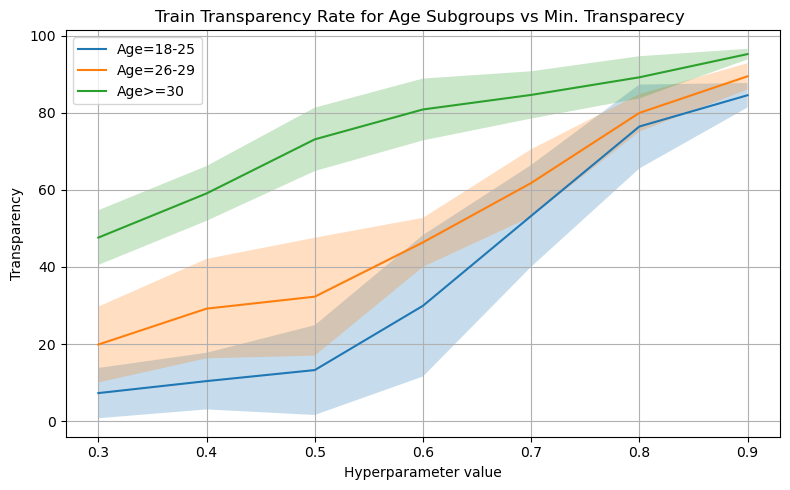

In [1195]:
plot_split(mean_subgroup, std_subgroup, hyperparams, condition_age, "Train Transparency Rate for Age Subgroups vs Min. Transparecy ")

In [1198]:
Path.cwd()

PosixPath('/Users/ziba/programming/optimization/HybridCorels-julien/HybridCORELS/test-ziba')